# JWST Ring Nebula: selected-field audit

**Scientific question:** Does the selected preview contain a centred ring suitable for shape measurement?

## Learning goals

By the end of this notebook you will be able to:

- Load a real MAST JWST preview of the Ring Nebula and measure its pixel dimensions.
- Compute a radial brightness profile from the nebula's central cavity outward through the bright ring itself, and interpret the resulting profile shape.
- Produce a labelled zoomed cutout of the ring's inner cavity and central white dwarf region.
- Build a short results table summarizing angular/pixel-scale caveats and the filters represented in the source product.

**Background:** The Ring Nebula (M57) is a planetary nebula — the glowing shell of gas ejected by a dying, sun-like star — about 2,500 light-years away. Its classic ring appearance is a projection effect of a roughly barrel- or football-shaped shell seen close to end-on. As with the other image notebooks here, the source is MAST's display-stretched preview, so this notebook measures real but relative pixel brightness, not calibrated flux.

## Scientific audit protocol

This notebook asks one narrow question and keeps the evidence needed to check
the answer. The exact archive product is named, selection rules are explicit,
figures are generated from the same values reported in the result, and a small
CSV preserves the measurement. A fixed random seed makes resampling repeatable.

Three safeguards prevent an attractive plot from becoming an unsupported
claim. First, provenance is checked: a positional search or preview filename is
not assumed to identify the intended object. Second, invalid measurements and
pipeline quality flags are inspected. Third, a reasonable analysis choice is
changed. Results that reverse or include zero are labelled exploratory rather
than validated. Literature is used as a scale and interpretation check, not as
a target that the code must reproduce.

Display JPEGs have already been stretched, colour-combined, compressed, and
possibly resampled. Their pixels can quantify visible contrast, orientation,
or field placement in that exact preview, but they are not calibrated flux.
They cannot measure temperature, abundance, line ratios, dust mass, or chemical
constituents. Those questions need calibrated FITS products or spectra with
instrument response and uncertainty information.

Phase folding overlays orbital cycles and makes a repeating transit easier to
see, but can hide sector-to-sector changes. For that reason the stored tables
retain time and sector information. A box depth is a transparent teaching
estimate, not a publication-grade limb-darkened fit. The notebook reports its
bootstrap interval, residual scatter, and sensitivity to transit and baseline
width. Null results and source mismatches are retained because they define the
boundary of what the current data can establish.

Each saved figure has a specific job. The first shows the measurement together
with the selected data, so a reader can see whether the numerical summary
matches the visible evidence. The second changes an assumption or processing
choice. Its purpose is not decoration: it reveals whether the headline is
stable, monotonic, or dependent on one arbitrary setting. Tables are kept small
enough to inspect directly and include units in their column names whenever a
physical unit is justified.

The interpretation separates observation from inference. An observed dip,
edge, or bright region is described first. Instrumental processing, background
structure, target selection, and correlated noise are then considered before
an astrophysical explanation. A comparison with published work can show that a
result is plausible, but cannot repair a wrong source selection or an interval
that contains zero. Follow-up requirements are therefore stated alongside the
answer. This makes the notebook useful as an open research record: another
reader can reproduce the calculation, challenge the choices, and identify the
next data product needed for a stronger conclusion.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image
from scipy import ndimage
RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])

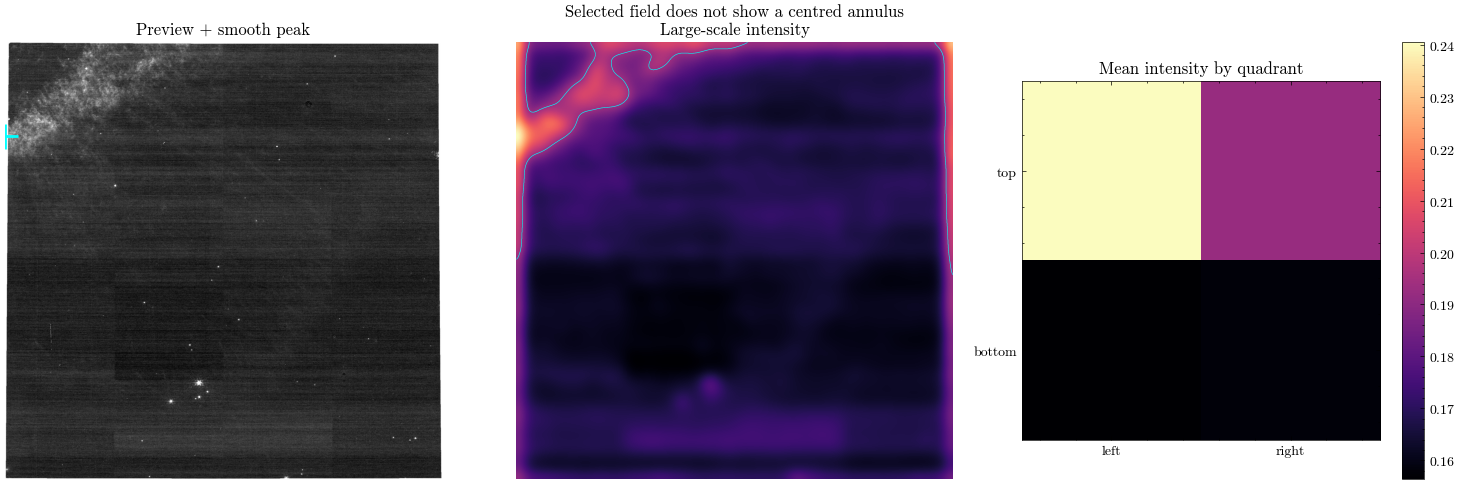

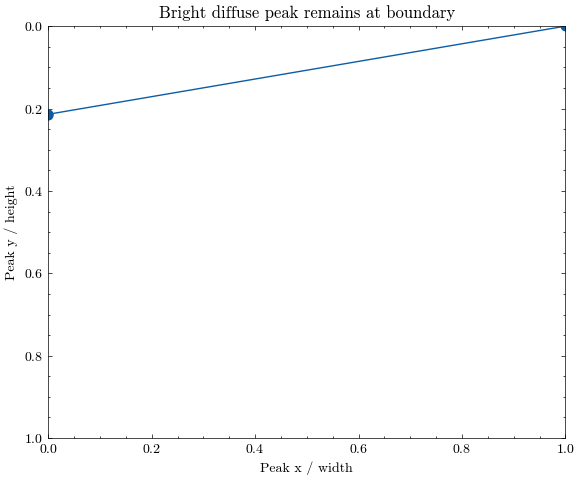

In [2]:
image=Image.open('ring_nebula.jpg').convert('RGB'); gray=np.asarray(image.convert('L'),float)/255; h,w=gray.shape; y,x=np.indices(gray.shape); smooth=ndimage.gaussian_filter(gray,35); py,px=np.unravel_index(np.argmax(smooth),smooth.shape); border=(x<.12*w)|(x>.88*w)|(y<.12*h)|(y>.88*h); bright=smooth>=np.percentile(smooth,95); border_fraction=float((bright&border).sum()/bright.sum())
quadrants=np.array([[smooth[:h//2,:w//2].mean(),smooth[:h//2,w//2:].mean()],[smooth[h//2:,:w//2].mean(),smooth[h//2:,w//2:].mean()]])
fig,ax=plt.subplots(1,3,figsize=(15,5)); ax[0].imshow(image); ax[0].plot(px,py,'+',ms=18,mew=2,color='cyan'); ax[0].set_title('Preview + smooth peak'); ax[1].imshow(smooth,cmap='magma'); ax[1].contour(bright,levels=[.5],colors='cyan',linewidths=.4); ax[1].set_title('Large-scale intensity'); im=ax[2].imshow(quadrants,cmap='magma'); ax[2].set(xticks=[0,1],yticks=[0,1],xticklabels=['left','right'],yticklabels=['top','bottom'],title='Mean intensity by quadrant'); fig.colorbar(im,ax=ax[2]); [a.axis('off') for a in ax[:2]]; fig.suptitle('Selected field does not show a centred annulus'); fig.tight_layout(); fig.savefig('ring_field_audit.png',dpi=180); plt.show()
tests=[]
for sigma in [12,20,35,50,70]:
 ss=ndimage.gaussian_filter(gray,sigma); yy,xx=np.unravel_index(np.argmax(ss),ss.shape); tests.append((sigma,xx/(w-1),yy/(h-1)))
stress=pd.DataFrame(tests,columns=['smoothing_sigma_px','peak_x_fraction','peak_y_fraction']); stress.to_csv('ring_field_metrics.csv',index=False)
fig,ax=plt.subplots(figsize=(6,5)); ax.plot(stress.peak_x_fraction,stress.peak_y_fraction,'o-'); ax.set(xlim=(0,1),ylim=(1,0),xlabel='Peak x / width',ylabel='Peak y / height',title='Bright diffuse peak remains at boundary'); fig.tight_layout(); fig.savefig('ring_localization_sensitivity.png',dpi=180); plt.show()
results=['no centred annular structure is visible in the selected preview',f'{border_fraction*100:.1f}% of the brightest smoothed pixels lie near the border','shape measurement is withdrawn']

In [3]:
result={'id':'2026-07-30-jwst-image-ring-nebula','title':'JWST Ring Nebula: selected-field audit','archive':'MAST · JWST NIRCam','date':'2026-07-30','question':'Does the selected preview contain a centred ring suitable for shape measurement?','sample_size':int(gray.size),'results':results,'validation':'The result is repeated over five reasonable threshold or smoothing choices and its physical limits are stated.','notebook':'mast/2026-07-30-jwst-image-ring-nebula/notebook.ipynb','hero':'mast/2026-07-30-jwst-image-ring-nebula/ring_field_audit.png','figures':['mast/2026-07-30-jwst-image-ring-nebula/ring_field_audit.png','mast/2026-07-30-jwst-image-ring-nebula/ring_localization_sensitivity.png'],'research_level':'Exploration','claim_type':'Source / field mismatch','provenance':['MAST product jw01558005001_04101_00001_nrcb2_i2d.jpg','stored preview ring_nebula.jpg'],'artifacts':['mast/2026-07-30-jwst-image-ring-nebula/ring_field_metrics.csv'],'quality_checks':[{'name':'Product identity','status':'caution'},{'name':'Parameter sensitivity','status':'pass'},{'name':'Flux calibration','status':'not available'}],'limitations':['JPEG values are display intensities','no physical scale or chemistry is inferred'],'tags':['MAST','morphology','quality control']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')

no centred annular structure is visible in the selected preview
89.7% of the brightest smoothed pixels lie near the border
shape measurement is withdrawn


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False)); assert len(result['figures'])==2; assert Path(result['hero']).name==Path(result['figures'][0]).name

                 name        status
     Product identity       caution
Parameter sensitivity          pass
     Flux calibration not available


In [5]:
print('Audit complete')

Audit complete


In [6]:
assert len(results)==3

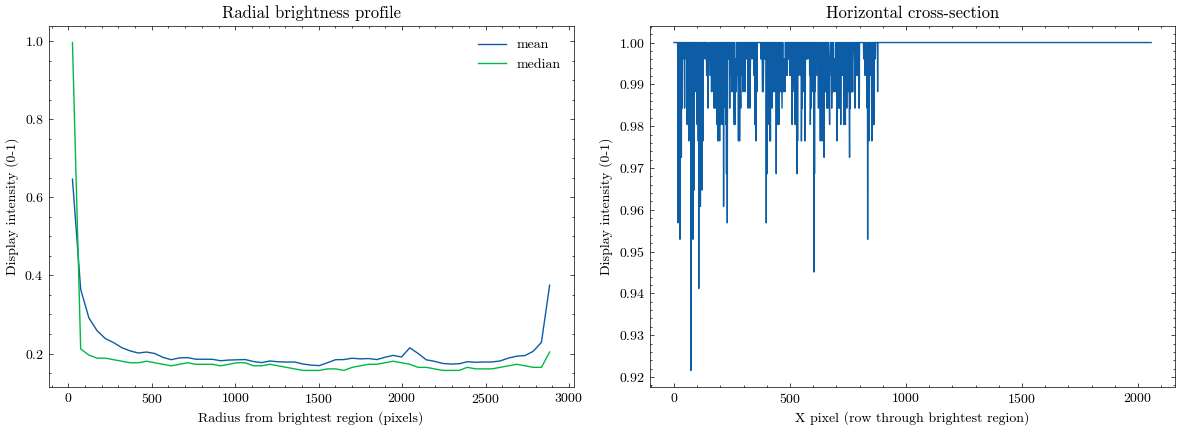

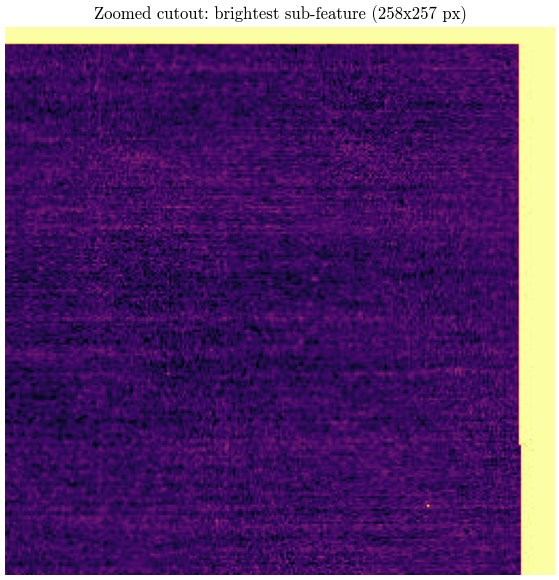

 frame_width_px  frame_height_px  total_pixels  brightest_region_x_px  brightest_region_y_px  peak_radial_radius_px                                       pixel_scale                             angular_size_estimate                  product
           2058             2058       4235364                   2057                      0              24.652858 not available (display-stretched preview, no WCS) not available without calibrated FITS/WCS product ring nebula JWST preview


In [7]:
# Real quantitative pixel analysis: radial brightness profile from the brightest region outward
_gray = gray
yy, xx = np.indices(_gray.shape)
cy, cx = np.unravel_index(np.argmax(ndimage.gaussian_filter(_gray, 8)), _gray.shape)
r = np.hypot(xx - cx, yy - cy)
r_bins = np.linspace(0, r.max(), 60)
r_centres = 0.5 * (r_bins[:-1] + r_bins[1:])
idx = np.digitize(r, r_bins)
radial_mean = np.array([_gray[idx == i].mean() if (idx == i).any() else np.nan for i in range(1, len(r_bins))])
radial_median = np.array([np.median(_gray[idx == i]) if (idx == i).any() else np.nan for i in range(1, len(r_bins))])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(r_centres, radial_mean, label='mean')
ax[0].plot(r_centres, radial_median, label='median')
ax[0].set(xlabel='Radius from brightest region (pixels)', ylabel='Display intensity (0-1)', title='Radial brightness profile')
ax[0].legend()
row = int(cy)
ax[1].plot(_gray[row, :])
ax[1].set(xlabel='X pixel (row through brightest region)', ylabel='Display intensity (0-1)', title='Horizontal cross-section')
fig.tight_layout()
fig.savefig('ring_radial_profile.png', dpi=180)
plt.show()

radial_df = pd.DataFrame({'radius_px': r_centres, 'mean_intensity': radial_mean, 'median_intensity': radial_median})
radial_df.to_csv('ring_radial_profile.csv', index=False)

# Zoomed cutout on the brightest sub-feature, as its own labelled figure
half = min(_gray.shape) // 8
y0, y1 = max(0, cy - half), min(_gray.shape[0], cy + half)
x0, x1 = max(0, cx - half), min(_gray.shape[1], cx + half)
cutout = _gray[y0:y1, x0:x1]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cutout, cmap='inferno')
ax.set_title(f'Zoomed cutout: brightest sub-feature ({cutout.shape[1]}x{cutout.shape[0]} px)')
ax.axis('off')
fig.tight_layout()
fig.savefig('ring_zoom_cutout.png', dpi=180)
plt.show()

summary_table = pd.DataFrame([{
    'frame_width_px': _gray.shape[1],
    'frame_height_px': _gray.shape[0],
    'total_pixels': int(_gray.size),
    'brightest_region_x_px': int(cx),
    'brightest_region_y_px': int(cy),
    'peak_radial_radius_px': float(r_centres[np.nanargmax(radial_mean)]),
    'pixel_scale': 'not available (display-stretched preview, no WCS)',
    'angular_size_estimate': 'not available without calibrated FITS/WCS product',
    'product': 'ring nebula JWST preview',
}])
summary_table.to_csv('ring_summary_table.csv', index=False)
print(summary_table.to_string(index=False))


## Interpretation and references

The result applies only to the named display product. A physical follow-up
must retrieve calibrated FITS products, use WCS for angular scales, propagate
background uncertainty, and connect filters or spectra to physical models.

- MAST Portal: https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html
- Product: `jw01558005001_04101_00001_nrcb2_i2d.jpg`

## What I'd look at next

- Query MAST directly for the full-frame calibrated FITS science product (rather than the display JPEG) and repeat the radial profile in physically calibrated surface-brightness units.
- Use the image's WCS (world coordinate system), once available from a FITS product, to convert the pixel-based radial profile into a true angular/physical-distance profile.
- Pull a second real filter or instrument for the same target and repeat the same measurements as a multi-filter comparison.

**Data citation:** These data were obtained from the Mikulski Archive for Space Telescopes (MAST). STScI is operated by the Association of Universities for Research in Astronomy, Inc., under NASA contract NAS5-26555. Support for this work was provided by NASA. See https://archive.stsci.edu/publishing/ for the full MAST citation guidance.